# Библиотеки

In [82]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import seaborn as sns

## 9.5 Проверка распределения "на нормальность"

In [2]:
filepath = './data/...'

In [3]:
df = pd.DataFrame({
    'col1': [1.2, 2.3, 3.1, 4.5, 5.6],
    'col2': [7.8, 8.9, 6.5, 3.4, 2.1],
    'col3': ['a', 'b', 'c', 'd', 'e'],
    'col4': [10.1, 9.8, 9.0, 8.4, 7.3]
})

df

,col1,col2,col3,col4
0,1.2,7.8,a,10.1
1,2.3,8.9,b,9.8
2,3.1,6.5,c,9.0
3,4.5,3.4,d,8.4
4,5.6,2.1,e,7.3


In [4]:
ndf = df.select_dtypes(include=['number'])

### Шапиро-Уилка

In [8]:
for column in ndf.columns:
    s, p = stats.shapiro(ndf[column])
    print(f"{column}: p={p}")

col1: p=0.9395082526178811
col2: p=0.5900247580808732
col4: p=0.7660770303438794


In [77]:
# pvals = []
# n = 10000

# for _ in range(n):
#     sample = np.random.normal(0, 1, 1000)
#     # sample = np.random.exponential(1, 100)
#     s, p = stats.shapiro(sample)
#     pvals.append(p)

# pvals = np.array(pvals)

samples = np.random.normal(loc=0, scale=1, size=(1000, 100))
pvals = np.apply_along_axis(lambda x: stats.shapiro(x)[1], 1, samples)

In [78]:
pval_mean = (pvals < 0.05).mean()
ese = (pvals < 0.05).std(ddof=1) / len(pvals)**0.5

print(f"{pval_mean}, ci: [{pval_mean - 1.96*ese:.3f}, {pval_mean + 1.96*ese:.3f}]")

0.045, ci: [0.032, 0.058]


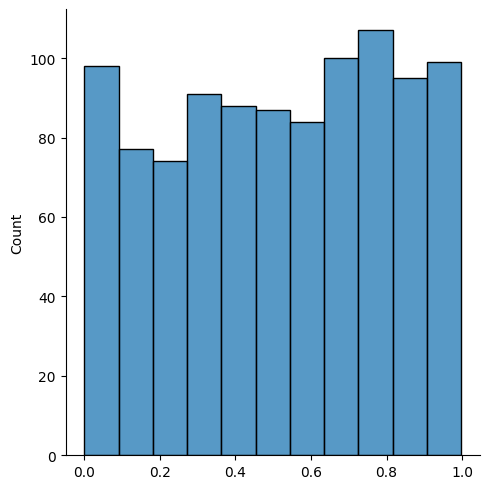

In [80]:
sns.displot(pvals)

### Колмогорова-Смирнова

In [9]:
for column in ndf.columns:
    mean = ndf[column].mean()
    std = ndf[column].std()
    s, p = stats.kstest(ndf[column], 'norm', args=(mean, std))
    print(f"{column}: p={p}")

col1: p=0.9981170404099345
col2: p=0.9559768090883124
col4: p=0.9850254163232818


In [24]:
pvals = []

n = 1000
for _ in range(1000):
    sample = np.random.normal(0, 1, 100)
    # sample = np.random.exponential(1, 100)
    s, p = stats.kstest(sample, 'norm', args=(0, 1))
    pvals.append(p)

print(f"{(np.array(pvals) < 0.05).mean()}")

0.048


### pingouin

In [85]:
summary = pd.DataFrame({
    "mean": ndf.mean(),
    "median": ndf.median(),
    "mode": ndf.mode().iloc[0],
    "skewness": ndf.skew(),
    "kurtosis": ndf.kurt()
})

summary

,mean,median,mode,skewness,kurtosis
col1,3.34,3.1,1.2,0.169942,-1.244473
col2,5.74,6.5,2.1,-0.348592,-2.244228
col4,8.92,9.0,7.3,-0.603934,-0.603275


array([[<Axes: title={'center': 'col1'}>,
        <Axes: title={'center': 'col2'}>],
       [<Axes: title={'center': 'col4'}>, <Axes: >]], dtype=object)

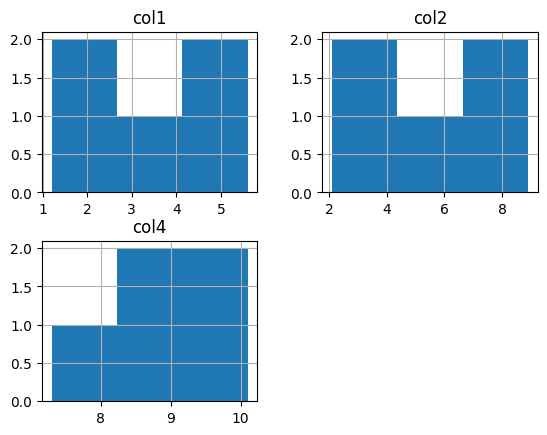

In [86]:
ndf.hist(bins=3)

#### Q-Q plot

- Синие точки  это наши данные, отсортированные по квантилям (Q в названии это квантиль\quantile).
- Серая диагональ  идеальное нормальное распределение (чем ближе фактические данные (синие точки) к ней - тем более вероятность что имеем дело с нормальным распределением).
- Красная линия линейная аппроксимация наших данных (синих точек).
- R² = 0.991 коэффициент детерминации отображающий насколько точки близки к линии апроксимации (мы еще его разберем в регрессиях далее в курсе)
- Широкие доверительные интервалы (красные пунктирные линии) показывают, что при таком размере выборки отклонения легко "теряются".

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

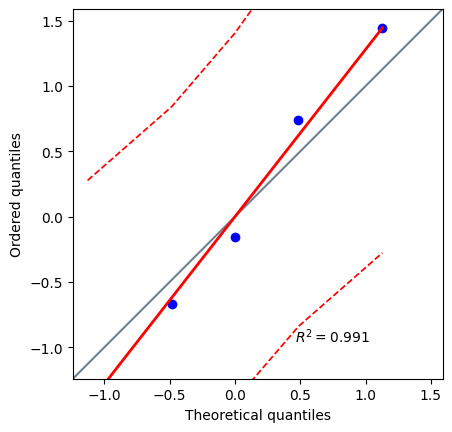

In [87]:
pg.qqplot(ndf['col1'], dist='norm')

In [83]:
pg.normality(df, method='shapiro', alpha=0.05)

,W,pval,normal
col1,0.980925,0.939508,True
col2,0.929067,0.590025,True
col4,0.954052,0.766077,True
